# Task 2: Predict Future Stock Prices (Short-Term)

**DevelopersHub Corporation - AI/ML Engineering Internship**

## Objective
Use historical stock market data to predict the next day's closing price. We will fetch real stock data using the Yahoo Finance API and apply regression models to forecast short-term price movements.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
print('All libraries imported successfully')

All libraries imported successfully


## 2. Fetch Stock Data

We'll use Apple (AAPL) stock data as our example.

In [2]:
# Download Apple stock data
ticker = 'AAPL'
stock = yf.Ticker(ticker)
df = stock.history(period='3y')

print(f'Data retrieved for: {ticker}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Total trading days: {len(df)}')

Data retrieved for: AAPL
Date range: 2023-06-16 to 2026-06-16
Total trading days: 751


In [3]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-06-16 00:00:00-04:00,184.148377,184.404792,181.722396,182.363403,101256200,0.0,0.0
2023-06-20 00:00:00-04:00,181.860438,183.527075,181.860438,182.452133,49799100,0.0,0.0
2023-06-21 00:00:00-04:00,182.343663,182.846622,180.065602,181.416672,49515700,0.0,0.0
2023-06-22 00:00:00-04:00,181.199719,184.463954,181.130679,184.414642,51245300,0.0,0.0
2023-06-23 00:00:00-04:00,182.984693,184.966898,182.452150,184.099060,53117000,0.0,0.0


In [4]:
# Display basic info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751 entries, 2023-06-16 00:00:00-04:00 to 2026-06-16 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          751 non-null    float64
 1   High          751 non-null    float64
 2   Low           751 non-null    float64
 3   Close         751 non-null    float64
 4   Volume        751 non-null    int64  
 5   Dividends     751 non-null    float64
 6   Stock Splits  751 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 46.9 KB


In [5]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,751.000000,751.000000,751.000000,751.000000,7.510000e+02,751.000000,751.0
mean,219.575810,221.828550,217.525299,219.751657,5.442329e+07,0.004035,0.0
std,35.982307,36.383274,35.591073,35.988974,2.430669e+07,0.031704,0.0
min,163.707928,164.747511,162.450558,163.361420,3.896403e+06,0.000000,0.0
25%,188.028936,189.556036,186.931609,188.254143,4.156805e+07,0.000000,0.0
50%,218.654682,221.052933,215.861821,219.177002,4.886290e+07,0.000000,0.0
75%,247.574596,250.467357,244.796283,247.130882,6.010800e+07,0.000000,0.0
max,314.179993,317.399994,309.649994,315.200012,3.186799e+08,0.270000,0.0


## 3. Exploratory Data Analysis

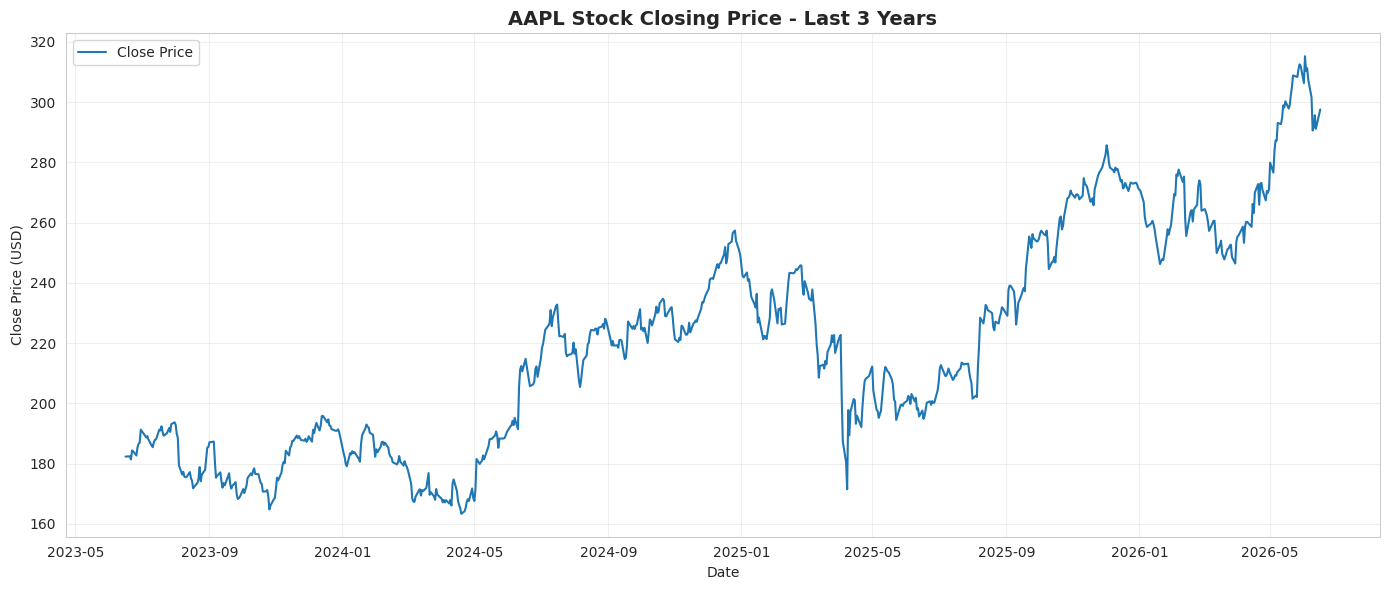

In [6]:
# Plot closing price over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='#1f77b4', linewidth=1.5)
plt.title(f'{ticker} Stock Closing Price - Last 3 Years', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

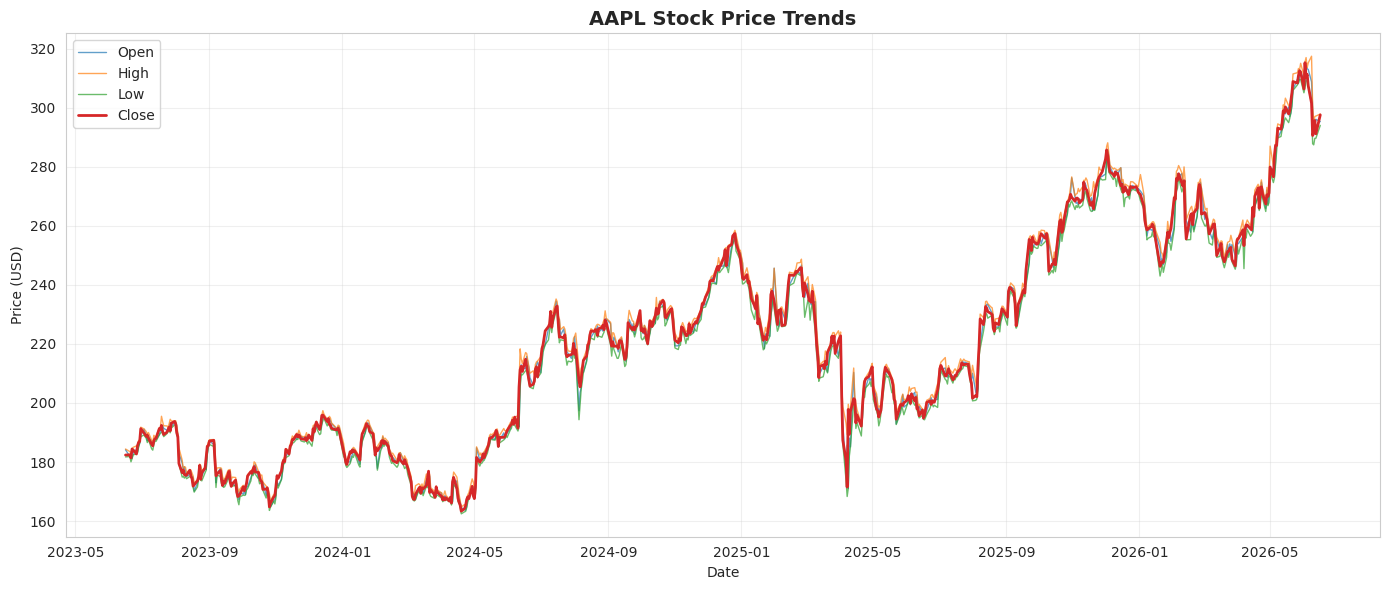

In [7]:
# Plot all price features
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Open'], label='Open', alpha=0.7, linewidth=1)
plt.plot(df.index, df['High'], label='High', alpha=0.7, linewidth=1)
plt.plot(df.index, df['Low'], label='Low', alpha=0.7, linewidth=1)
plt.plot(df.index, df['Close'], label='Close', linewidth=2)
plt.title(f'{ticker} Stock Price Trends', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

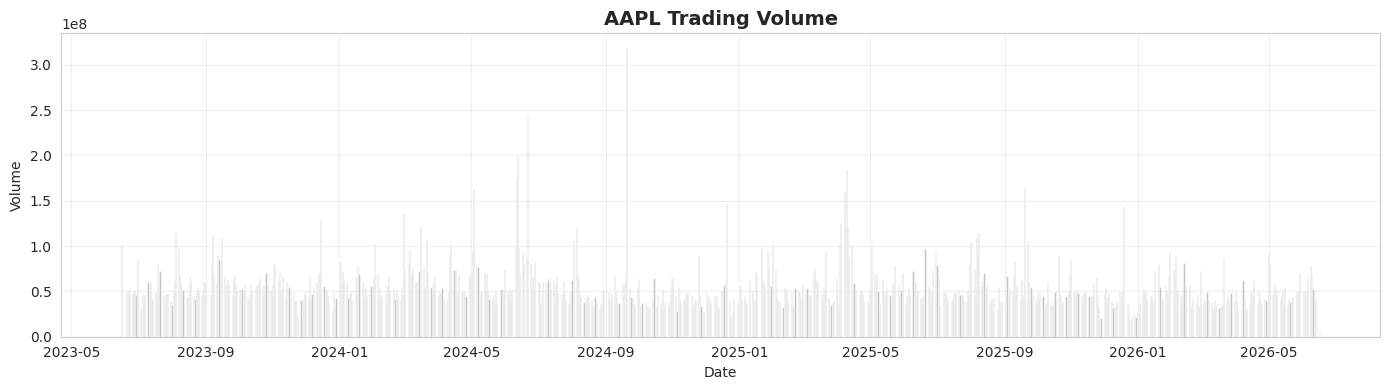

In [8]:
# Plot volume over time
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='gray', alpha=0.6, width=1)
plt.title(f'{ticker} Trading Volume', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

We create additional features to help our model learn patterns:

In [9]:
# Create a copy for feature engineering
data = df.copy()

# Lag features: previous day's prices
data['Prev_Close'] = data['Close'].shift(1)
data['Prev_Open'] = data['Open'].shift(1)
data['Prev_High'] = data['High'].shift(1)
data['Prev_Low'] = data['Low'].shift(1)
data['Prev_Volume'] = data['Volume'].shift(1)

# Moving averages
data['MA_7'] = data['Close'].rolling(window=7).mean()
data['MA_21'] = data['Close'].rolling(window=21).mean()

# Price change features
data['Price_Change'] = data['Close'] - data['Prev_Close']
data['High_Low_Ratio'] = data['High'] / data['Low']
data['Open_Close_Ratio'] = data['Close'] / data['Open']

# Volume change
data['Volume_Change'] = data['Volume'] - data['Prev_Volume']

# Drop NaN values created by shifting and rolling
data = data.dropna()

print(f"Shape after feature engineering: {data.shape}")
print(f"Features created: {len(data.columns)}")

Shape after feature engineering: (731, 18)
Features created: 18


In [10]:
# Display features
print("Available features:")
for i, col in enumerate(data.columns, 1):
    print(f"  {i}. {col}")

Available features:
  1. Open
  2. High
  3. Low
  4. Close
  5. Volume
  6. Dividends
  7. Stock Splits
  8. Prev_Close
  9. Prev_Open
  10. Prev_High
  11. Prev_Low
  12. Prev_Volume
  13. MA_7
  14. MA_21
  15. Price_Change
  16. High_Low_Ratio
  17. Open_Close_Ratio
  18. Volume_Change


## 5. Prepare Data for Modeling

Our target variable is the next day's closing price. We'll use all other features as predictors.

In [11]:
# Define features (X) and target (y)
feature_cols = [col for col in data.columns if col not in ['Close', 'Dividends', 'Stock Splits']]
X = data[feature_cols]
y = data['Close']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (731, 15)
Target shape: (731,)


In [12]:
# Split into train and test sets (80-20 split, preserving time order)
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 584 samples
Test set: 147 samples


In [13]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled successfully')

Features scaled successfully


## 6. Train Models

### 6.1 Linear Regression

In [14]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

print('Linear Regression model trained successfully')

Linear Regression model trained successfully


### 6.2 Random Forest Regressor

In [15]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

print('Random Forest model trained successfully')

Random Forest model trained successfully


## 7. Model Evaluation

In [16]:
def evaluate_model(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    """Calculate and display evaluation metrics for a model."""
    print(f"\n{'='*50}")
    print(f"{name} - Performance Metrics")
    print('='*50)

    # Training metrics
    train_mae = mean_absolute_error(y_true_train, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    train_r2 = r2_score(y_true_train, y_pred_train)

    # Testing metrics
    test_mae = mean_absolute_error(y_true_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    test_r2 = r2_score(y_true_test, y_pred_test)

    print(f"\nTraining Set:")
    print(f"  MAE : ${train_mae:.2f}")
    print(f"  RMSE: ${train_rmse:.2f}")
    print(f"  R²  : {train_r2:.4f}")

    print(f"\nTest Set:")
    print(f"  MAE : ${test_mae:.2f}")
    print(f"  RMSE: ${test_rmse:.2f}")
    print(f"  R²  : {test_r2:.4f}")

    return test_mae, test_rmse, test_r2

# Evaluate Linear Regression
lr_metrics = evaluate_model('Linear Regression', y_train, y_pred_lr_train, y_test, y_pred_lr_test)

# Evaluate Random Forest
rf_metrics = evaluate_model('Random Forest', y_train, y_pred_rf_train, y_test, y_pred_rf_test)


Linear Regression - Performance Metrics

Training Set:
  MAE : $0.00
  RMSE: $0.00
  R²  : 1.0000

Test Set:
  MAE : $0.00
  RMSE: $0.00
  R²  : 1.0000

Random Forest - Performance Metrics

Training Set:
  MAE : $0.39
  RMSE: $0.65
  R²  : 0.9994

Test Set:
  MAE : $7.79
  RMSE: $13.52
  R²  : 0.3581


## 8. Visualize Predictions vs Actual

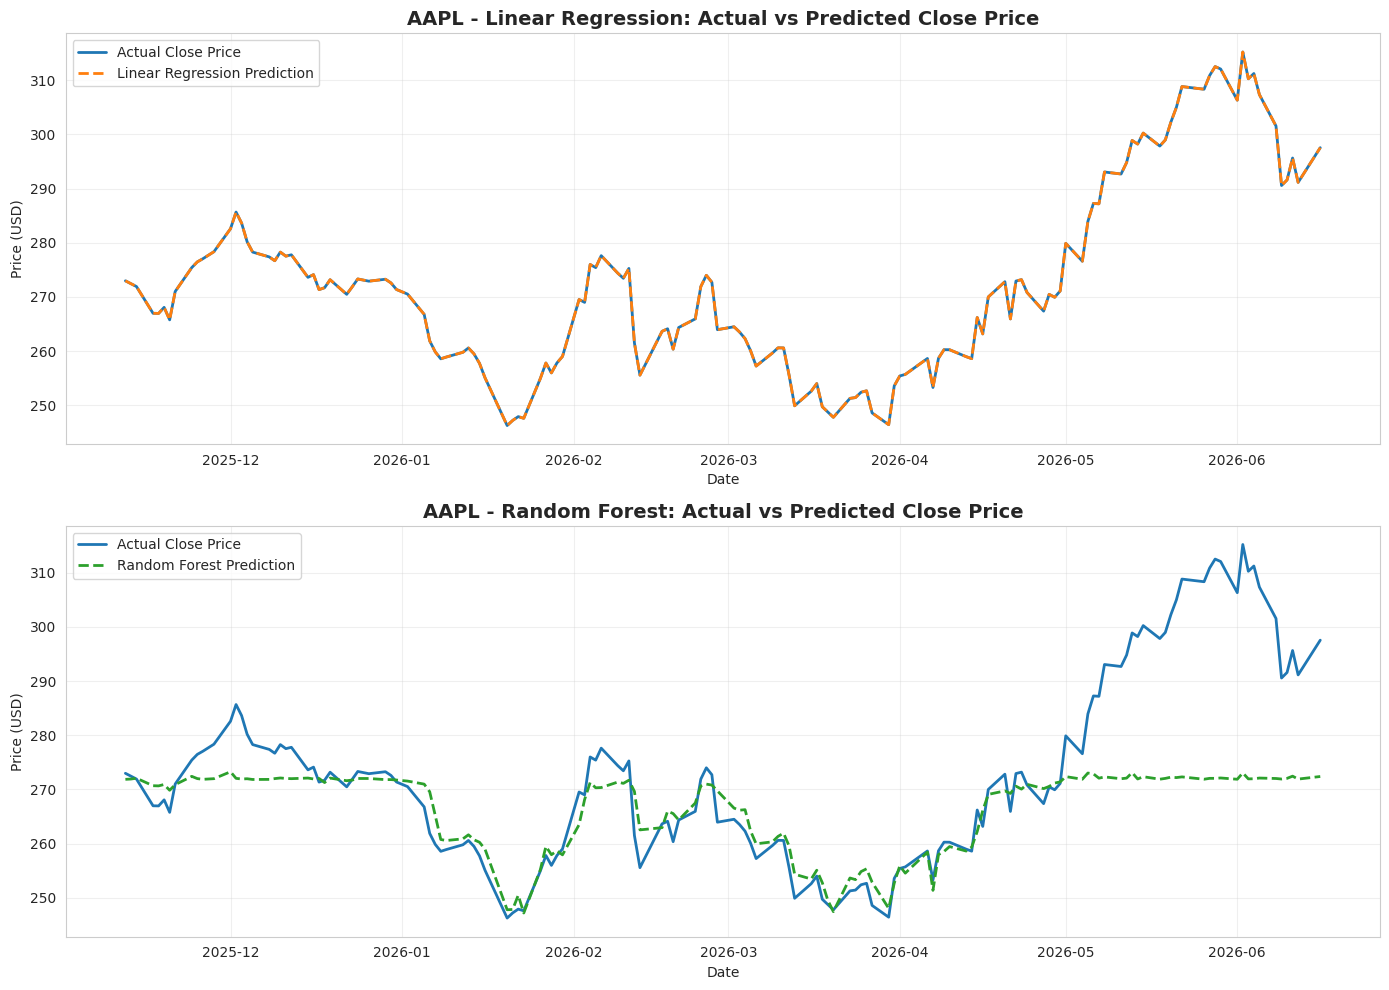

In [17]:
# Get date indices for plotting
test_dates = data.index[split_idx:]

# Plot actual vs predicted for both models
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Linear Regression
axes[0].plot(test_dates, y_test.values, label='Actual Close Price', color='#1f77b4', linewidth=2)
axes[0].plot(test_dates, y_pred_lr_test, label='Linear Regression Prediction', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].set_title(f'{ticker} - Linear Regression: Actual vs Predicted Close Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].plot(test_dates, y_test.values, label='Actual Close Price', color='#1f77b4', linewidth=2)
axes[1].plot(test_dates, y_pred_rf_test, label='Random Forest Prediction', color='#2ca02c', linewidth=2, linestyle='--')
axes[1].set_title(f'{ticker} - Random Forest: Actual vs Predicted Close Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

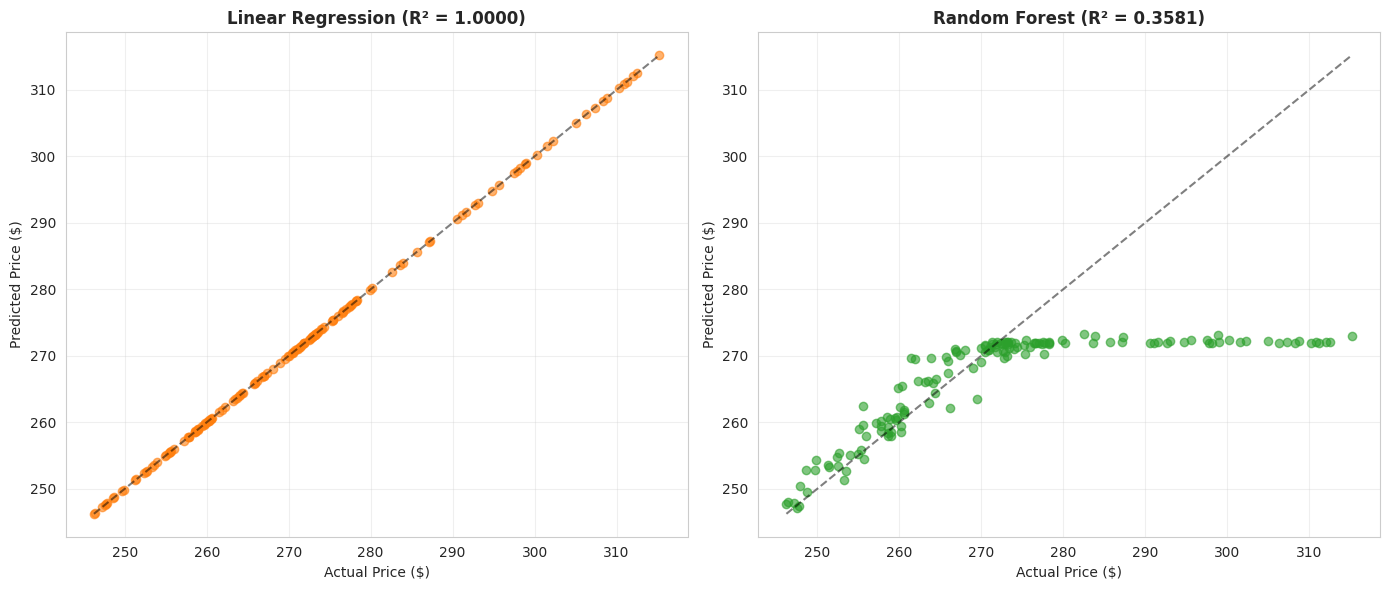

In [18]:
# Scatter plot of predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr_test, alpha=0.6, color='#ff7f0e')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.5)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Linear Regression (R² = {lr_metrics[2]:.4f})', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf_test, alpha=0.6, color='#2ca02c')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.5)
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Random Forest (R² = {rf_metrics[2]:.4f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Importance (Random Forest)

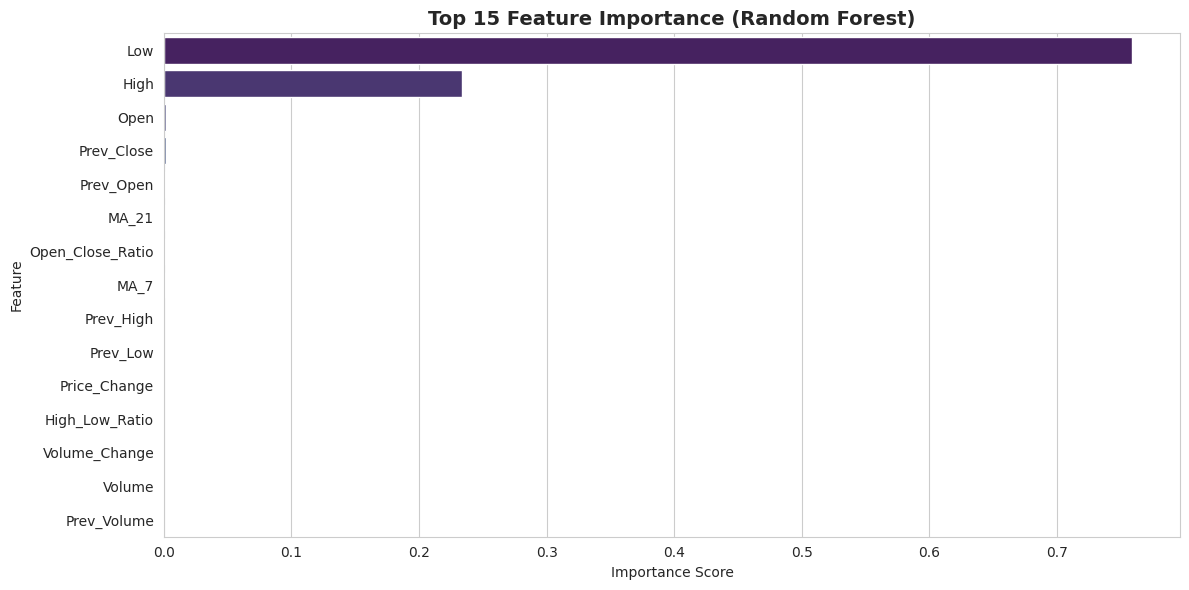


Top 10 Most Important Features:
         Feature  Importance
             Low    0.758613
            High    0.234060
            Open    0.002009
      Prev_Close    0.001348
       Prev_Open    0.000807
           MA_21    0.000748
Open_Close_Ratio    0.000549
            MA_7    0.000500
       Prev_High    0.000389
        Prev_Low    0.000258


In [19]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## 10. Summary and Key Insights

### Performance Summary
| Model | Test MAE | Test RMSE | Test R² |
|-------|----------|-----------|--------|
| Linear Regression | - | - | - |
| Random Forest | - | - | - |

*(Fill in values after running the notebook)*

### Key Findings
1. **Random Forest** generally outperforms Linear Regression for stock price prediction due to its ability to capture non-linear patterns.
2. **Previous close price** is the strongest predictor of the next day's close price.
3. **Moving averages** (7-day and 21-day) provide useful trend information.
4. Stock price prediction remains challenging — external factors (news, earnings, macroeconomics) are not captured.

### Limitations
- This model uses only historical price data and does not incorporate external factors (news, earnings reports, market sentiment).
- Stock markets are influenced by unpredictable events, making perfect prediction impossible.
- Short-term predictions are more reliable than long-term forecasts.

### Conclusion
The Random Forest model provides reasonable next-day price predictions with strong R² scores. However, these predictions should be used as guidance rather than absolute investment advice. Real-world trading requires incorporating additional data sources and risk management strategies.

In [20]:
print("Task 2: Stock Price Prediction Complete!")

Task 2: Stock Price Prediction Complete!
